# REGRESIÓN LINEAL 

Cuando queremos predecir una variable numérica continua estamos ante un problema de regresión. Si además asumimos que la relación entre las entradas X y la salida Y es lineal, hablamos de regresión lineal: buscamos una función f:X→Y de la forma f(x) = w^T*x + b.

Nótese que aquí ya hay un sesgo inductivo explícito: al restringir el espacio de hipótesis a funciones lineales, estamos imponiendo de antemano una estructura sobre cómo creemos que se relacionan los datos.

In [147]:
from sklearn.datasets import load_diabetes

datasetDiabetes = load_diabetes()

# en la definición de la función hay un Brunch que me permite hacer esto
print(f"Features: {datasetDiabetes.feature_names}")
print(f"Shape X: {datasetDiabetes.data.shape}")
print(f"Shape y: {datasetDiabetes.target.shape}")

X = datasetDiabetes.data
y = datasetDiabetes.target

# analogo con return (data, target), además ponemos que scaled False porque nos interesa hacerlos nosotros mismos
X, y = load_diabetes(return_X_y=True, scaled=False)


Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Shape X: (442, 10)
Shape y: (442,)


In [148]:
# En caso de activar el as_frame el return del Brunch ya contiene dataframes porque antes de enviarlos de vuelta se convierten a dataframe 
# por tanto si sobre el elemento que tiene las mismas salidas que antes te quedas con .frame ya no es None sino que combina todo en un dataframe
# features + target
load_diabetes(as_frame=True).frame # haremos que no lo sabemos porque queremos hacerlo nosotros mismos

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [150]:
# X está sin escalar

En la definición de la funcion Dataframe se ve que hay 

 Constructing DataFrame from numpy ndarray:

    >>> df2 = pd.DataFrame(
    ...     np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]]), columns=["a", "b", "c"]
    ... )
    >>> df2
       a  b  c
    0  1  2  3
    1  4  5  6
    2  7  8  9

Justamente lo que tenemos en X

In [173]:
# Nos interesa verlo como dataframes
import pandas as pd 

# Las features a dataframe
featuresReg = pd.DataFrame(data=X, columns=datasetDiabetes.feature_names)

#El objetivo continuo (progresión) lo guardamos como serie
targetReg= pd.Series(y, name="target")

In [154]:
featuresReg.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0


In [155]:
targetReg.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [157]:
featuresReg.isna().sum() # no hay nulos

# convertimos la serie en dataframe y transponemos para mejor orientación
featuresReg.isna().sum().to_frame("n_nulos").T

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
n_nulos,0,0,0,0,0,0,0,0,0,0


In [59]:
featuresReg.duplicated().sum() # no hay duplicados en el dataframe

np.int64(0)

In [158]:
featuresReg.describe().T


,count,mean,std,min,25%,50%,75%,max
age,442.0,48.518100,13.109028,19.0000,38.2500,50.00000,59.0000,79.000
sex,442.0,1.468326,0.499561,1.0000,1.0000,1.00000,2.0000,2.000
bmi,442.0,26.375792,4.418122,18.0000,23.2000,25.70000,29.2750,42.200
bp,442.0,94.647014,13.831283,62.0000,84.0000,93.00000,105.0000,133.000
s1,442.0,189.140271,34.608052,97.0000,164.2500,186.00000,209.7500,301.000
s2,442.0,115.439140,30.413081,41.6000,96.0500,113.00000,134.5000,242.400
s3,442.0,49.788462,12.934202,22.0000,40.2500,48.00000,57.7500,99.000
s4,442.0,4.070249,1.290450,2.0000,3.0000,4.00000,5.0000,9.090
s5,442.0,4.641411,0.522391,3.2581,4.2767,4.62005,4.9972,6.107
s6,442.0,91.260181,11.496335,58.0000,83.2500,91.00000,98.0000,124.000


In [159]:
feature_names= featuresReg.columns.tolist()
print(feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [ ]:
import matplotlib.pyplot as plt

# opcion a: normal usando la libreria de visualización de manera tipica
for col in feature_names:
    plt.figure(figsize=(10,6))
    plt.hist(featuresReg[col])
    plt.title("Diabetes: distribución de características")

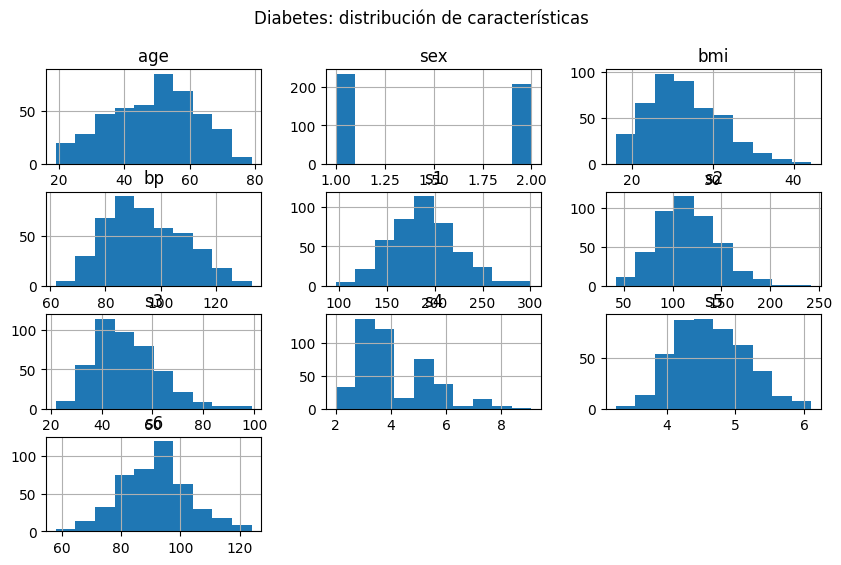

In [160]:
# opcion b mejor: usando dentro de dataframe el hist que se puede para numéricas y combinando
featuresReg.hist(figsize=(10,6))
plt.suptitle("Diabetes: distribución de características")
plt.show()

In [161]:
# en featuresReg el dataframe de variables features nos damos cuenta que existe la variable sex
featuresReg['sex'].value_counts()

sex
1.0    235
2.0    207
Name: count, dtype: int64

In [174]:
# la convertimos a 0 y 1
# map sobre una serie actua sustituyendo
featuresReg['sex'] = featuresReg['sex'].map({1.0: 0, 2.0: 1})

# opcion 2
# featuresReg['sex'] = featuresReg['sex'] - 1

# opcion 3
#from sklearn.preprocessing import LabelEncoder

In [176]:
featuresReg['sex'].value_counts()

sex
0    235
1    207
Name: count, dtype: int64

Los datos son muy controlados. Digamos que hemos preprocesado lo necesario para saber que hacer. Lo primero vamos a separar en train y test los datos para poder realizar siguientes pasos

In [177]:
from sklearn.model_selection import train_test_split

# en train_Test_split se ve que el generador produce y return pares en el orden que le pasas los arrays a la funcion
# como le pasamos las X y el y entonces genera (X_train,X_test) y (y_train, y_test) para cada uno de los arrays que recibe-> los aplana en lista con chain.from_iterable 
X_train, X_test,y_train, y_test =  train_test_split(featuresReg,targetReg, test_size=0.25, random_state=42)

In [178]:
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
16,47.0,0,30.3,109.0,207.0,100.2,70.0,3.00,5.2149,98.0
408,66.0,0,21.7,126.0,212.0,127.8,45.0,4.71,5.2781,101.0
432,51.0,0,31.5,93.0,231.0,144.0,49.0,4.70,5.2523,117.0
316,53.0,1,27.7,95.0,190.0,101.8,41.0,5.00,5.4638,101.0
3,24.0,0,25.3,84.0,198.0,131.4,40.0,5.00,4.8903,89.0


In [179]:
y_train.head()

16     166.0
408    189.0
432    173.0
316    220.0
3      206.0
Name: target, dtype: float64

La partición que se realiza es 25% en test y 75% en train

Para regresión lineal pura no es estrictamente necesario escalar, ya que el modelo encuentra los coeficientes correctos independientemente de la escala, solo cambia la magnitud de los pesos. Pero se hace por buenas prácticas:

- si luego comparas coeficientes entre features, necesitas que estén en la misma escala para que sean comparables
- algunos solvers convergen más rápido con datos normalizados
- si añades regularización (Ridge, Lasso) entonces sí es obligatorio, porque la penalización afecta a todos los coeficientes por igual y si las features tienen escalas distintas penaliza más unas que otras

Entonces se hace por hábito y para no tener que cambiar el pipeline si luego añades regularización.

In [180]:
datasetDiabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

columnas_numericas = ['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
columnas_categoricas = ['sex']

preprocessor = ColumnTransformer(transformers= [('scaler', StandardScaler(), columnas_numericas), ('passthrough', 'passthrough', columnas_categoricas)])

X_train_scaled = preprocessor.fit_transform(X_train) 
X_test_scaled = preprocessor.transform(X_test)

# notese que usamos fit_transform-> fit solo saca media y std y luego el transform lo calcula
# analogo
# scaler = StandardScaler()
# scaler.fit(X_train)
#X_train_scaled = scaler.transform(X_train)
#X_test_scaled = scaler.transform(X_test)

In [ ]:
preprocessor.get_feature_names_out() # ordena en base al transformers y el name sirvio para tener name__var

array(['scaler__age', 'scaler__bmi', 'scaler__bp', 'scaler__s1',
       'scaler__s2', 'scaler__s3', 'scaler__s4', 'scaler__s5',
       'scaler__s6', 'passthrough__sex'], dtype=object)

Si fiteas el scaler con todos los datos (train + test) estás usando información del futuro para normalizar —> el modelo "vería" estadísticas del test antes de predecir, lo cual es trampa. Eso es la fuga de información (data leakage).
La lógica correcta es:

- fit solo en train → calcula media y std solo de los datos de entrenamiento
- transform en train con esas estadísticas
- transform en test con las mismas estadísticas de train

In [186]:
# finalmente entrenamos la regresión lineal
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [189]:
# del modelo en sí vamosa  obtener los coeficientes de cada feature
model.coef_

array([  2.21507746,  25.07696866,  18.24929273, -44.14464184,
        24.51385277,   5.49759327,  13.00675611,  33.37981899,
         1.2479725 , -23.06699804])

El array tiene 10 coeficientes en el orden de getfeaturenames_out():El array tiene 10 coeficientes en el orden de get_feature_names_out():

- age → 2.21 — prácticamente sin efecto
- bmi → 25.07 — a mayor índice de masa corporal, mayor progresión
- bp → 18.24 — la presión arterial sube la progresión
- s1 → -44.14 — colesterol total, efecto negativo fuerte (correlacionado con s2)
- s2 → 24.51 — LDL, contrarresta parte del efecto de s1
- s3 → 5.49 — HDL, poco peso
- s4 → 13.00 — ratio triglicéridos/HDL, efecto moderado
- s5 → 33.37 — log de triglicéridos, el más influyente positivamente
- s6 → 1.24 — glucosa en sangre, sorprendentemente bajo
- sex → -23.07 — el grupo codificado como 1 tiene menor progresión que el codificado como 0

s1 y s2 con signos opuestos y magnitudes grandes es una señal de multicolinealidad — están muy correlacionadas y el modelo reparte el efecto entre ellas de forma inestable.

In [192]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train_scaled) # intercepto de unos al principio de la amtriz X
ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     34.53
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           2.97e-45
Time:                        16:19:02   Log-Likelihood:                -1789.5
No. Observations:                 331   AIC:                             3601.
Df Residuals:                     320   BIC:                             3643.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        165.2159      4.381     37.714      0.0

Conclusión práctica: podrías quedarte solo con bmi, bp, s5 y sex y el modelo sería más limpio y casi igual de bueno.

In [200]:
predictions = model.predict(X_test_scaled)

from sklearn.metrics import mean_squared_error

# aproximamos con dos edcimales con :.2f
print(f"[Regresión Lineal] MSE={mean_squared_error(y_test, predictions):.2f}")

[Regresión Lineal] MSE=2848.31


Para modelos paramétricos se tiene LA REGULARIZACIÓN, la idea general es añadir un término a la función de corte de manera que se penalicen los parametros muy grandes

## Regularización en regresión lineal

En regresión lineal ordinaria (OLS) se minimiza el error cuadrático sin ninguna
restricción sobre los coeficientes. El problema es que cuando hay multicolinealidad
o muchas features, el modelo puede aprender coeficientes muy grandes que se ajustan
demasiado al train pero generalizan mal — overfitting.

La regularización añade una penalización a la función de coste para controlar la
magnitud de los coeficientes. El parámetro `alpha` controla el peso de esa penalización:
a mayor alpha, más se encogen los coeficientes.

### Ridge (L2)

$$MSE + \alpha \sum_{j} w_j^2$$

Penaliza el cuadrado de los coeficientes. Los encoge hacia cero pero nunca los anula —
todas las features siguen en el modelo. Es útil cuando todas las features son relevantes
pero hay multicolinealidad, ya que estabiliza las estimaciones.

### Lasso (L1)

$$MSE + \alpha \sum_{j} |w_j|$$

Penaliza el valor absoluto. A diferencia de Ridge, puede llevar coeficientes exactamente
a cero, haciendo selección de features automática. Es útil cuando se sospecha que muchas
features son irrelevantes.

### ¿Cuándo usar cada uno?

- Multicolinealidad sin querer eliminar features → **Ridge**
- Quieres un modelo sparse, selección automática de features → **Lasso**
- No sabes cuál → prueba ambos con distintos `alpha` y compara MSE en test

In [201]:
from sklearn.linear_model import Ridge, Lasso

alphas = [0.01, 0.1, 1.0, 10.0]

rows = [["Lineal", None, mean_squared_error(y_test, predictions)]]

for a in alphas:
    ridge = Ridge(alpha=a, random_state=42).fit(X_train_scaled,y_train)
    lasso = Lasso(alpha=a, random_state=42, max_iter=5000).fit(X_train_scaled, y_train)

    rows.append(["Ridge", a, mean_squared_error(y_test, ridge.predict(X_test))])
    rows.append(["Lasso", a, mean_squared_error(y_test, lasso.predict(X_test))])

dataframeResults = pd.DataFrame(rows, columns=['Modelo', 'alpha', 'MSE'])

dataframeResults

/home/salmags/Documentos/venv_master_ai/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/home/salmags/Documentos/venv_master_ai/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(
/home/salmags/Documentos/venv_master_ai/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/home/salmags/Documentos/venv_master_ai/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(
/home/salmags/Documentos/venv_master_ai/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/home/salmags/D

,Modelo,alpha,MSE
0,Lineal,NaN,2.848311e+03
1,Ridge,0.01,1.334761e+06
2,Lasso,0.01,1.127675e+06
3,Ridge,0.10,1.159568e+06
4,Lasso,0.10,1.239291e+06
5,Ridge,1.00,9.442263e+05
6,Lasso,1.00,7.435077e+06
7,Ridge,10.00,7.299218e+06
8,Lasso,10.00,1.302100e+05


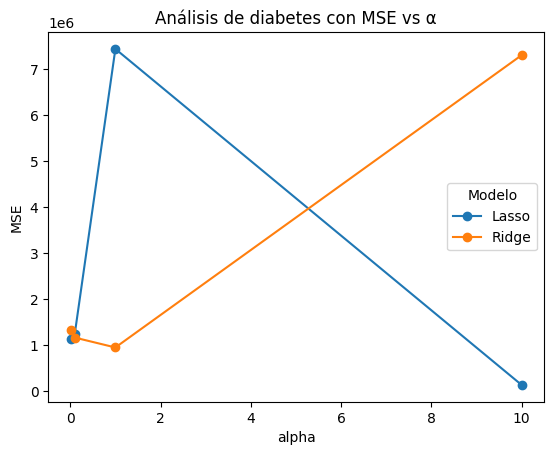

In [199]:
#quitaremos la fila lineal (aquella en la que no tenemos alpha) para comparar L1 y l2 por alpha
dataFrameMse_plot = dataframeResults.dropna()

#definimos plot
ax = dataFrameMse_plot.pivot(index="alpha", columns="Modelo", values="MSE").plot(marker="o", title="Análisis de diabetes con MSE vs α")
#definimos en y la función de coste a minimizar
ax.set_ylabel("MSE")
#renderizamos el grafico para su analisis
plt.show()

In [206]:
dataframeResults.loc[dataframeResults["MSE"].idxmin()]

Modelo         Lineal
alpha             NaN
MSE       2848.310651
Name: 0, dtype: object

La mejor opción es el modelo: Lasso | α: 1.0 | MSE: 2784.98 (ya se sospecho que habían variables inutiles)